In [ ]:
from dataset import Mixed_CBCT_dataset

dataset = Mixed_CBCT_dataset(dst_list=["knee_cbct"], out_res=512, dst_root="../data")
data = dataset[0]
print(data.keys())

mixed_dataset: ['knee_cbct']
CBCT_dataset, name: knee_cbct, split: train, len: 821.
Loaded Z-lengths for 865 patients.
dict_keys(['name', 'points', 'angles', 'proj_points', 'projs', 'p_gt', 'dst_vec', 'dst_name'])


In [2]:
from utils import convert_cuda
from torch.utils.data import DataLoader

# make it torch tensor and cuda
loader = DataLoader([data], batch_size=1, shuffle=False, num_workers=0)
data = next(iter(loader))

data = convert_cuda(data)
points, p_gt, proj_points, projs = (
    data["points"],
    data["p_gt"],
    data["proj_points"],
    data["projs"][0],
)
print(points.shape, p_gt.shape, proj_points.shape, projs.shape)
points = points.reshape(128, 128, -1, 3)
p_gt = p_gt.reshape(128, 128, -1)
proj_points = proj_points.reshape(2, 128, 128, -1, 2)
print(points.shape, p_gt.shape, proj_points.shape)

torch.Size([1, 1966080, 3]) torch.Size([1, 1, 1966080]) torch.Size([1, 2, 1966080, 2]) torch.Size([2, 1, 512, 512])
torch.Size([128, 128, 120, 3]) torch.Size([128, 128, 120]) torch.Size([2, 128, 128, 120, 2])


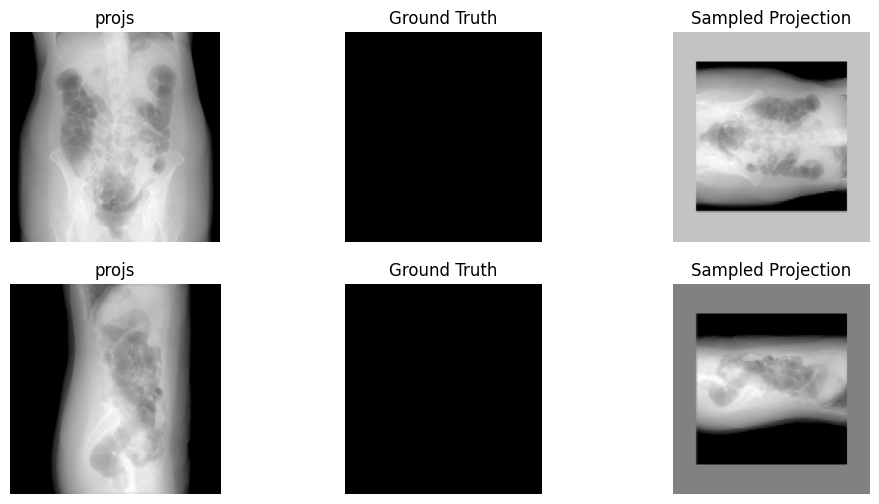

In [4]:
import matplotlib.pyplot as plt
from torch.nn.functional import grid_sample

index = -1
dims = [2, 1]
# sample via grid_sample
sampled_projs = []
plt.figure(figsize=(12, 6))
for angle_idx in range(projs.shape[0]):
    sampled_projs.append(
        grid_sample(
            projs[angle_idx : angle_idx + 1],  # .transpose(2, 3),
            proj_points[angle_idx : angle_idx + 1].select(dims[angle_idx], index),
            align_corners=True,
            mode="bilinear",
            padding_mode="zeros",
        )
    )
    plt.subplot(2, 3, 1 + angle_idx * 3)
    plt.imshow(projs[angle_idx][0].cpu(), cmap="gray")
    plt.title("projs")
    plt.axis("off")
    plt.subplot(2, 3, 2 + angle_idx * 3)
    plt.imshow(p_gt.select(dims[angle_idx] - 1, index).cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    plt.subplot(2, 3, 3 + angle_idx * 3)
    plt.imshow(sampled_projs[angle_idx][0, 0].cpu().detach(), cmap="gray")
    plt.title("Sampled Projection")
    plt.axis("off")

In [6]:
print(projs.shape)

torch.Size([2, 1, 512, 512])


In [ ]:
import torch

torch.empty(10, 20, 30, 40).select(0, 5).shape
print(proj_points.shape)
print(p_gt.shape)

torch.Size([2, 128, 128, 120, 2])
torch.Size([128, 128, 120])


In [ ]:
print(points.shape)
print(points[0, ..., 0])

torch.Size([128, 128, 120, 3])
tensor([[-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883],
        [-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883],
        [-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883],
        ...,
        [-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883],
        [-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883],
        [-0.9883, -0.9883, -0.9883,  ..., -0.9883, -0.9883, -0.9883]],
       device='cuda:0')


In [ ]:
i = 0
print(proj_points.shape)
print(proj_points[0, :, i, :].shape)
print(proj_points[0, :, i, :].min())
print(proj_points[0, :, i, :].max())

torch.Size([2, 128, 128, 120, 2])
torch.Size([128, 120, 2])
tensor(-0.9894, device='cuda:0')
tensor(1.0011, device='cuda:0')
